In [3]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split

In [4]:
class Node:
    """一個簡單的決策樹節點。"""

    def __init__(self, feature_index=None, threshold=None, left=None, right=None, *, value=None):
        """
        初始化決策樹的節點。

        :param feature_index: 用於分割的特徵索引
        :param threshold: 分割的閾值
        :param left: 左子樹
        :param right: 右子樹
        :param value: 如果節點是葉節點，則為其值
        """
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        """檢查節點是否為葉節點。"""
        return self.value is not None


class DecisionTree:
    """一個簡單的決策樹分類器。"""

    def __init__(self, max_depth=None):
        """
        初始化決策樹。

        :param max_depth: 樹的最大深度
        """
        self.max_depth = max_depth
        self.root = None

    def _fit(self, X, y, depth):
        """
        遞迴地生長樹。

        :param X: 數據集的特徵
        :param y: 目標變量
        :param depth: 樹的當前深度
        """
        n_samples, n_features = X.shape
        num_labels = len(set(y))

        # 停止條件
        if depth >= self.max_depth or num_labels == 1 or n_samples == 0:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)

        # 貪婪選擇最佳分割以獲得最佳增益
        best_feat, best_thresh = self._best_criteria(X, y, n_features)
        left_idxs, right_idxs = self._split(X[:, best_feat], best_thresh)

        left = self._fit(X[left_idxs, :], y[left_idxs], depth + 1)
        right = self._fit(X[right_idxs, :], y[right_idxs], depth + 1)
        return Node(best_feat, best_thresh, left, right)

    def _most_common_label(self, y):
        """找出目標數組中最常見的標籤。"""
        return max(set(y), key=list(y).count)

    def _best_criteria(self, X, y, n_features):
        """找出最佳分割標準。"""
        best_gain = -1
        split_idx, split_thresh = None, None
        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            thresholds = set(X_column)
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold
        return split_idx, split_thresh

    def _information_gain(self, y, X_column, split_thresh):
        """計算分割的信息增益。"""
        # 父節點的損失
        parent_entropy = self._entropy(y)

        # 生成分割
        left_idxs, right_idxs = self._split(X_column, split_thresh)

        if len(left_idxs) == 0 or len(right_idxs) == 0:
            return 0

        # 計算子節點的加權平均損失
        n = len(y)
        n_l, n_r = len(left_idxs), len(right_idxs)
        e_l, e_r = self._entropy(y[left_idxs]), self._entropy(y[right_idxs])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r

        # 信息增益
        ig = parent_entropy - child_entropy
        return ig

    def _entropy(self, y):
        """計算標籤數組的熵。"""
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])

    def _split(self, X_column, split_thresh):
        """根據閾值分割數據。"""
        left_idxs = np.argwhere(X_column <= split_thresh).flatten()
        right_idxs = np.argwhere(X_column > split_thresh).flatten()
        return left_idxs, right_idxs

    def fit(self, X, y):
        """將決策樹擬合到數據集。"""
        self.root = self._fit(X, y, 0)

    def predict(self, X):
        """預測每個樣本在X中的類別。"""
        return [self._predict_sample(x, self.root) for x in X]

    def _predict_sample(self, x, tree):
        """遞迴函數來預測單個樣本。"""
        if tree.is_leaf_node():
            return tree.value
        if x[tree.feature_index] <= tree.threshold:
            return self._predict_sample(x, tree.left)
        return self._predict_sample(x, tree.right)


In [15]:


# Load the Breast Cancer Wisconsin (Diagnostic) dataset
iris = datasets.load_breast_cancer()
X = iris.data
y = iris.target

# For a compact visualization, use the first 100 samples and first two tumor features
X = X[:100, :2]
y = y[:100]



X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the decision tree on the training data
tree = DecisionTree(max_depth=3)
tree.fit(X_train, y_train)

# Evaluate the decision tree on the test data
predictions = tree.predict(X_test)
accuracy = np.mean(predictions == y_test)
accuracy


0.85

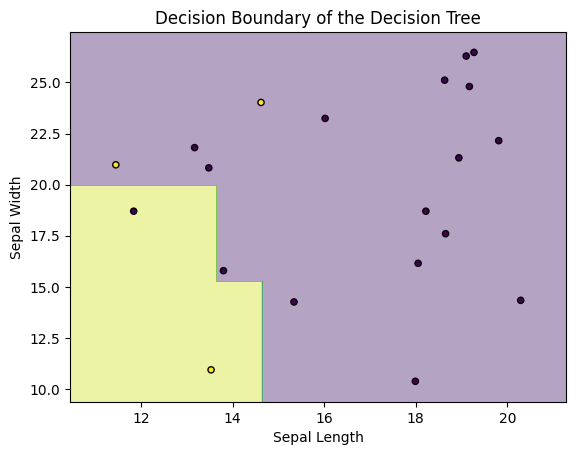

In [16]:
import matplotlib.pyplot as plt

def plot_decision_boundary(tree, X, y):
    """
    Plots the decision boundary created by the decision tree.
    
    :param tree: The trained decision tree
    :param X: Feature data
    :param y: Target labels
    """
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Predict on the mesh grid
    Z = tree.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.array(Z).reshape(xx.shape)

    # Plotting
    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    plt.xlabel('Mean Radius')
    plt.ylabel('Mean Texture')
    plt.title('Decision Boundary of the Decision Tree')
    plt.show()

# Plot the decision boundary on the held-out breast-cancer samples
plot_decision_boundary(tree, X_test, y_test)


In [20]:
from sklearn.datasets import load_breast_cancer

# 加载乳腺癌数据集
data = load_breast_cancer()

# 特征名称
print("Feature names:")
print(data.feature_names)

# 类别名称
print("\nTarget names:")
print(data.target_names)

import pandas as pd

# 转换为 Pandas DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target  # 添加目标列

# 打印前 5 行
print(df.head())



Feature names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Target names:
['malignant' 'benign']
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.